# Quantum Mechanics Postulates, Dirac Notation & the Bloch Sphere
### A hands-on Python notebook for - Quantum Computing Education Series by Trinexis

**What this notebook is for.** In the lectures we *saw* quantum behaviour twice - interference in the
double-slit experiment, and repeatability / incompatibility / erasure in the Stern–Gerlach (SG) cascades.
This notebook turns those observations into **mathematical structure**. By the end you will be able to
write a qubit state, measure it, watch it collapse, build operators, check whether they are Hermitian or
unitary, decompose any 2×2 matrix in the Pauli basis, and place a qubit on the Bloch sphere - all in code
you can re-run and modify yourself.


**Contents**
1. Setup & helper tools
2. The five postulates of quantum mechanics (for quantum computing)
3. Ket, Bra, Operators - Dirac notation
4. Inner products and outer products
5. Hermitian and unitary operators
6. Pauli matrices and the Pauli basis
7. The Bloch sphere
8. Exercises to play with

---
## 1. Setup & helper tools

We use only **NumPy** (linear algebra) and **Matplotlib** (plots). The helper functions below just make
complex vectors and matrices print nicely and keep the physics code uncluttered.

**Convention reminder.** A ket $|\psi\rangle$ is a *column* vector. In NumPy we store it as a 1-D complex
array. The bra $\langle\psi|$ is its conjugate transpose. The inner product $\langle\phi|\psi\rangle$ is
therefore `np.vdot(phi, psi)` - note `np.vdot` conjugates its **first** argument, exactly matching the bra.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  #  (registers the 3D projection)

np.set_printoptions(precision=3, suppress=True)
rng = np.random.default_rng(42)   # fixed seed -> reproducible "measurements"


# ---------- pretty printing ----------
def fmt_c(z, p=3):
    "Format a complex number compactly (hide tiny round-off and trivial parts)."
    z = complex(z)
    re = 0.0 if abs(z.real) < 1e-12 else round(z.real, p)
    im = 0.0 if abs(z.imag) < 1e-12 else round(z.imag, p)
    if im == 0:
        return f"{re:g}"
    if re == 0:
        return f"{im:g}i"
    sign = "+" if im >= 0 else "-"
    return f"{re:g} {sign} {abs(im):g}i"


def show_ket(psi, name="psi"):
    "Print a state vector as a column and in the |0>,|1> basis."
    terms = " + ".join(f"({fmt_c(a)})|{i}>" for i, a in enumerate(psi))
    col = ",  ".join(fmt_c(a) for a in psi)
    print(f"|{name}> = [ {col} ]^T   =   {terms}")


def show_matrix(M, name="A"):
    "Print a small complex matrix row by row."
    print(f"{name} =")
    for row in np.atleast_2d(M):
        print("   [ " + ",  ".join(f"{fmt_c(z):>10}" for z in row) + " ]")


print("Setup complete. NumPy", np.__version__)

Setup complete. NumPy 2.0.2


---
## 2. The five postulates of quantum mechanics

Each postulate below is the *formal name* for something the SG cascades already showed us. We state it,
then immediately demonstrate it in code. Keep the running thread in mind.

We work with a **single qubit**, the simplest non-trivial quantum system. Its state space is $\mathbb{C}^2$.

In [2]:
# Computational basis (the SG-z eigenstates: "spin up" and "spin down")
ket0 = np.array([1, 0], dtype=complex)   # |0>  ==  |up>
ket1 = np.array([0, 1], dtype=complex)   # |1>  ==  |down>

# The SG-x eigenstates, built as superpositions of |0>, |1>
ket_plus  = (ket0 + ket1) / np.sqrt(2)   # |+>
ket_minus = (ket0 - ket1) / np.sqrt(2)   # |->

show_ket(ket0,  "0")
show_ket(ket1,  "1")
show_ket(ket_plus,  "+")
show_ket(ket_minus, "-")

|0> = [ 1,  0 ]^T   =   (1)|0> + (0)|1>
|1> = [ 0,  1 ]^T   =   (0)|0> + (1)|1>
|+> = [ 0.707,  0.707 ]^T   =   (0.707)|0> + (0.707)|1>
|-> = [ 0.707,  -0.707 ]^T   =   (0.707)|0> + (-0.707)|1>


### Postulate 1 - State space
*The state of an isolated quantum system is a **unit** vector $|\psi\rangle$ in a complex inner-product
(Hilbert) space.* For a qubit that space is $\mathbb{C}^2$, so
$$|\psi\rangle = \alpha|0\rangle + \beta|1\rangle, \qquad |\alpha|^2 + |\beta|^2 = 1 .$$

Two things to verify in code: states are **normalized**, and the overall (global) phase $e^{i\theta}$
carries no physical meaning.

In [3]:
def norm(psi):
    return np.sqrt(np.vdot(psi, psi).real)

# A made-up state, then normalized
psi = np.array([1+1j, 0.5], dtype=complex)
print("Before normalizing, norm =", round(norm(psi), 3))
lpsi = psi / norm(psi)
print("After  normaizing, norm =", round(norm(lpsi), 3))
show_ket(lpsi)

# Global phase: |psi> and e^{i theta}|psi> are the SAME physical state.
theta = 1.2345
psi_phased = np.exp(1j*theta) * psi
print("\nThe two vectors below differ only by a global phase e^{i*theta}:")
show_ket(psi,        "psi")
show_ket(psi_phased, "e^{i.t} psi")
print("...and every measurement probability (squared magnitude) is identical - checked in Postulate 3.")

Before normalizing, norm = 1.5
After  normaizing, norm = 1.0
|psi> = [ 0.667 + 0.667i,  0.333 ]^T   =   (0.667 + 0.667i)|0> + (0.333)|1>

The two vectors below differ only by a global phase e^{i*theta}:
|psi> = [ 1 + 1i,  0.5 ]^T   =   (1 + 1i)|0> + (0.5)|1>
|e^{i.t} psi> = [ -0.614 + 1.274i,  0.165 + 0.472i ]^T   =   (-0.614 + 1.274i)|0> + (0.165 + 0.472i)|1>
...and every measurement probability (squared magnitude) is identical - checked in Postulate 3.


> **Misconception check.** $|\psi\rangle = \tfrac{1}{\sqrt2}(|0\rangle+|1\rangle)$ does **not** mean
> "the qubit is secretly 0 or 1 and we don't know which." It is the *complete* description. If it were
> secretly one definite value, the erasure experiment could never bring interference back - but it does.

### Postulate 2 - Observables are Hermitian operators
*Every measurable quantity is a Hermitian operator $\hat A = \hat A^\dagger$. The possible outcomes are its
eigenvalues; the states giving a definite outcome are its eigenvectors.*

"Spin along $z$" and "spin along $x$" are **different** SG magnet orientations, hence different operators
with different eigenbases. Below, $\hat Z$ has eigenvectors $|0\rangle,|1\rangle$ (the SG-z beams) and
$\hat X$ has eigenvectors $|+\rangle,|-\rangle$ (the SG-x beams), each with eigenvalues $\pm 1$.

In [4]:
Z = np.array([[1, 0],
              [0, -1]], dtype=complex)      # SG-z observable
X = np.array([[0, 1],
              [1, 0]], dtype=complex)       # SG-x observable

for name, A in [("Z", Z), ("X", X)]:
    vals, vecs = np.linalg.eigh(A)          # eigh -> real eigenvalues, orthonormal eigenvectors
    print(f"--- Observable {name} ---")
    show_matrix(A, name)
    print("  eigenvalues (possible outcomes):", vals.real)
    for v, lam in zip(vecs.T, vals):
        show_ket(v, f"eig({lam:+.0f})")
    print()

--- Observable Z ---
Z =
   [          1,           0 ]
   [          0,          -1 ]
  eigenvalues (possible outcomes): [-1.  1.]
|eig(-1)> = [ 0,  1 ]^T   =   (0)|0> + (1)|1>
|eig(+1)> = [ 1,  0 ]^T   =   (1)|0> + (0)|1>

--- Observable X ---
X =
   [          0,           1 ]
   [          1,           0 ]
  eigenvalues (possible outcomes): [-1.  1.]
|eig(-1)> = [ -0.707,  0.707 ]^T   =   (-0.707)|0> + (0.707)|1>
|eig(+1)> = [ 0.707,  0.707 ]^T   =   (0.707)|0> + (0.707)|1>



> **Why Hermitian?** It guarantees
> **real** eigenvalues and **orthogonal** eigenvectors
> (the SG beams never overlap). We prove both numerically in Section 5.

### Postulate 3 - The Born rule (measurement probabilities)
*Measuring observable $\hat A$ on $|\psi\rangle$ yields eigenvalue $\lambda_i$ with probability*
$$P(\lambda_i) = |\langle \lambda_i | \psi \rangle|^2 .$$
The complex number $\langle\lambda_i|\psi\rangle$ is the **amplitude**; its squared magnitude is what is
physical. This is the precise form of the rule that produced the double-slit fringes.

Let's confirm the famous result: a state prepared along $x$ (i.e. $|+\rangle$) gives **50/50** when measured
along $z$ - exactly the split you saw on the SG screen.

In [5]:
def born_probs(psi, observable):
    "Return (eigenvalues, probabilities) for measuring `observable` on state `psi`."
    vals, vecs = np.linalg.eigh(observable)
    amps  = vecs.conj().T @ psi          # each entry is <lambda_i | psi>
    probs = np.abs(amps)**2              # Born rule: square the magnitude
    return vals.real, probs.real

vals, probs = born_probs(ket_plus, Z)
print("Measuring |+> along Z:")
for lam, p in zip(vals, probs):
    print(f"   outcome {lam:+.0f}  ->  probability {p:.3f}")
print("Probabilities sum to", round(probs.sum(), 6), "(must be 1 - ties back to normalization).")

Measuring |+> along Z:
   outcome -1  ->  probability 0.500
   outcome +1  ->  probability 0.500
Probabilities sum to 1.0 (must be 1 - ties back to normalization).


Probabilities are one thing; let's also *simulate the experiment*. We run many single-shot measurements and
histogram the outcomes - a Monte-Carlo SG screen.

2000 shots of |+> measured along Z:  +1 -> 992   -1 -> 1008
Empirical split: 0.496 / 0.504   (theory: 0.500 / 0.500)


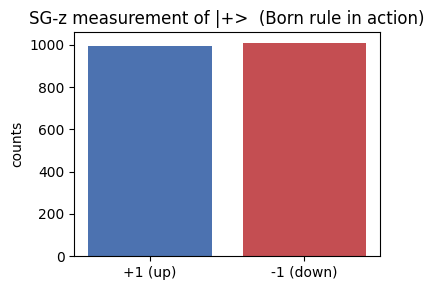

In [6]:
def measure_once(psi, observable):
    "Simulate a single measurement: returns (outcome_value, collapsed_state)."
    vals, vecs = np.linalg.eigh(observable)
    probs = np.abs(vecs.conj().T @ psi)**2
    probs = probs.real / probs.real.sum()
    i = rng.choice(len(vals), p=probs)
    return vals[i].real, vecs[:, i]          # collapsed state = chosen eigenvector (Postulate 4)

shots = 2000
outcomes = np.array([measure_once(ket_plus, Z)[0] for _ in range(shots)])
up   = np.count_nonzero(outcomes > 0)
down = shots - up
print(f"{shots} shots of |+> measured along Z:  +1 -> {up}   -1 -> {down}")
print(f"Empirical split: {up/shots:.3f} / {down/shots:.3f}   (theory: 0.500 / 0.500)")

plt.figure(figsize=(4, 3))
plt.bar(["+1 (up)", "-1 (down)"], [up, down], color=["#4C72B0", "#C44E52"])
plt.ylabel("counts"); plt.title("SG-z measurement of |+>  (Born rule in action)")
plt.tight_layout(); plt.show()

> **Misconception check.** This is *not* classical ignorance ("it was already up or down, we just learned
> which"). The amplitude $\langle\lambda_i|\psi\rangle$ can **interfere** with other amplitudes *before* it
> is squared - that is the whole double-slit story. Classical probabilities never interfere; amplitudes do.

### Postulate 4 - Collapse (the post-measurement state)
*Immediately after outcome $\lambda_i$, the state becomes the eigenvector $|\lambda_i\rangle$.*

This is **repeatability**, stated formally: once an atom leaves the "up" port of an SG-z magnet, a second
SG-z magnet gives "up" again - with certainty. We measure twice and check the second outcome is locked.

In [7]:
# Start in |+> (random along Z). Measure once -> collapse. Measure again -> must repeat.
first_val, collapsed = measure_once(ket_plus, Z)
print("First Z-measurement of |+>:")
print(f"   outcome = {first_val:+.0f}, state collapses to:")
show_ket(collapsed, "after")

# Now measure the collapsed state along Z many times: always the same answer.
repeats = [measure_once(collapsed, Z)[0] for _ in range(10)]
print("\nTen further Z-measurements of the collapsed state:", [f"{r:+.0f}" for r in repeats])
print("-> repeatability: the answer is locked in (Postulate 4).")

# But measure the SAME collapsed state along X -> randomness returns (incompatibility).
x_results = [measure_once(collapsed, X)[0] for _ in range(10)]
print("\nTen X-measurements of that same collapsed state:", [f"{r:+.0f}" for r in x_results])
print("-> collapsing along Z leaves the X-value completely undetermined again.")

First Z-measurement of |+>:
   outcome = +1, state collapses to:
|after> = [ 1,  0 ]^T   =   (1)|0> + (0)|1>

Ten further Z-measurements of the collapsed state: ['+1', '+1', '+1', '+1', '+1', '+1', '+1', '+1', '+1', '+1']
-> repeatability: the answer is locked in (Postulate 4).

Ten X-measurements of that same collapsed state: ['-1', '-1', '-1', '-1', '+1', '-1', '-1', '+1', '-1', '+1']
-> collapsing along Z leaves the X-value completely undetermined again.


> **Misconception check.** Collapse is **basis-specific**. Collapsing to a $z$-eigenstate makes the
> $x$-value totally random again - which is *why* slipping a $z$-measurement between two $x$-measurements
> destroys the $x$-correlation. Definite in one basis = superposition in any incompatible basis.

### Postulate 5 - Time evolution is unitary
*Between measurements, an isolated state evolves as $|\psi(t)\rangle = \hat U |\psi(0)\rangle$ with
$\hat U^\dagger \hat U = I$ (unitary).* Whatever happens when nobody is measuring must be deterministic and
must preserve total probability - and unitary operators are exactly the maps that do both.

In quantum computing these unitaries are the **gates**. The Hadamard gate is the unitary that rotates the
SG-z eigenbasis into the SG-x eigenbasis - it sends $|0\rangle \to |+\rangle$.

In [8]:
H = (1/np.sqrt(2)) * np.array([[1,  1],
                               [1, -1]], dtype=complex)   # Hadamard gate
show_matrix(H, "H")

print("\nIs H unitary?  H^dagger H == I :", np.allclose(H.conj().T @ H, np.eye(2)))
print("\nH|0> should equal |+>:")
show_ket(H @ ket0, "H|0>")
show_ket(ket_plus, "+")
print("Match:", np.allclose(H @ ket0, ket_plus))

H =
   [      0.707,       0.707 ]
   [      0.707,      -0.707 ]

Is H unitary?  H^dagger H == I : True

H|0> should equal |+>:
|H|0>> = [ 0.707,  0.707 ]^T   =   (0.707)|0> + (0.707)|1>
|+> = [ 0.707,  0.707 ]^T   =   (0.707)|0> + (0.707)|1>
Match: True


> **Misconception check.** "Quantum parallelism" is **not** classical parallel computing. A unitary moves a
> *single* state vector through a high-dimensional space; it does not spawn independent classical copies.
> The speed-up in algorithms (Stage 6) comes from *engineered interference*, not from running many
> classical branches at once.

---
## 3. Ket, Bra, Operators - Dirac notation

Everything below is **linear algebra you already know**, re-dressed in Dirac's notation. The payoff is that
inner products, projections and expectation values become fast to write and hard to get wrong - and this is
the notation every Qiskit / Quirk circuit and every QC paper uses.

In [9]:
# A KET is a column vector.
psi = np.array([0.6, 0.8j], dtype=complex)   # already unit norm: 0.36 + 0.64 = 1
show_ket(psi)

# A BRA is its conjugate transpose (a row vector).
bra = psi.conj()
print("\n<psi| =", ", ".join(fmt_c(z) for z in bra), " (a row; note the complex conjugation)")

# An OPERATOR is a matrix. Its matrix elements are A_ij = <i|A|j>.
A = np.array([[2, 1j],
              [-1j, 0]], dtype=complex)
basis = {0: ket0, 1: ket1}
print("\nMatrix elements A_ij = <i|A|j> :")
for i in (0, 1):
    for j in (0, 1):
        elem = np.vdot(basis[i], A @ basis[j])
        print(f"   A[{i}{j}] = <{i}|A|{j}> = {fmt_c(elem)}")

|psi> = [ 0.6,  0.8i ]^T   =   (0.6)|0> + (0.8i)|1>

<psi| = 0.6, -0.8i  (a row; note the complex conjugation)

Matrix elements A_ij = <i|A|j> :
   A[00] = <0|A|0> = 2
   A[01] = <0|A|1> = 1i
   A[10] = <1|A|0> = -1i
   A[11] = <1|A|1> = 0


---
## 4. Inner products and outer products

Two different ways to multiply a bra and a ket:

| Expression | Shape | Result | Meaning |
|---|---|---|---|
| $\langle\phi|\psi\rangle$ | (row)(col) | a **number** | amplitude / overlap |
| $|\psi\rangle\langle\phi|$ | (col)(row) | an **operator** | projector / transition |

### 4.1 Inner product
$\langle\phi|\psi\rangle$ is the amplitude in the Born rule. Key properties: conjugate symmetry
$\langle\phi|\psi\rangle = \overline{\langle\psi|\phi\rangle}$, and $\langle\psi|\psi\rangle = \||\psi\rangle\|^2 \ge 0$.

In [10]:
def inner(phi, psi):
    "<phi|psi> - note np.vdot conjugates its first argument, matching the bra."
    return np.vdot(phi, psi)

print("<0|+> =", fmt_c(inner(ket0, ket_plus)), "   (= 1/sqrt2, the z<-x overlap)")
print("<0|1> =", fmt_c(inner(ket0, ket1)),    "   (orthogonal basis states)")
print("<+|+> =", fmt_c(inner(ket_plus, ket_plus)), "   (normalized)")

# conjugate symmetry
phi = np.array([1, 1j], dtype=complex) / np.sqrt(2)
psi = np.array([1j, 1], dtype=complex) / np.sqrt(2)
print("\nConjugate symmetry  <phi|psi> = conj(<psi|phi>) :",
      np.allclose(inner(phi, psi), np.conj(inner(psi, phi))))

<0|+> = 0.707    (= 1/sqrt2, the z<-x overlap)
<0|1> = 0    (orthogonal basis states)
<+|+> = 1    (normalized)

Conjugate symmetry  <phi|psi> = conj(<psi|phi>) : True


**Orthonormality.** The computational basis $\{|0\rangle,|1\rangle\}$ and the $x$-basis
$\{|+\rangle,|-\rangle\}$ are each orthonormal - but they are *different* bases for the *same* space.
Incompatible observables correspond to non-aligned orthonormal bases (the rotated SG axes).

In [11]:
def gram(states):
    "Matrix of all pairwise inner products <i|j>; identity => orthonormal."
    n = len(states)
    return np.array([[inner(states[i], states[j]) for j in range(n)] for i in range(n)])

print("Gram matrix of {|0>, |1>}:")
show_matrix(gram([ket0, ket1]))
print("\nGram matrix of {|+>, |->}:")
show_matrix(gram([ket_plus, ket_minus]))
print("\nBoth are the identity -> each set is orthonormal.")

Gram matrix of {|0>, |1>}:
A =
   [          1,           0 ]
   [          0,           1 ]

Gram matrix of {|+>, |->}:
A =
   [          1,           0 ]
   [          0,           1 ]

Both are the identity -> each set is orthonormal.


### 4.2 Outer product, projectors, and the completeness relation
$|\psi\rangle\langle\phi|$ is an **operator**. The projector onto a basis state is $\hat P_i = |i\rangle\langle i|$;
it is *idempotent* ($\hat P_i^2 = \hat P_i$) and underlies collapse. Summing projectors over a complete basis
gives the identity - the **completeness relation** $\sum_i |i\rangle\langle i| = I$, the "insert a complete
set of states" move you will use constantly.

In [12]:
def outer(psi, phi):
    "|psi><phi| - an operator (column times row)."
    return np.outer(psi, phi.conj())

P0 = outer(ket0, ket0)     # projector onto |0>
P1 = outer(ket1, ket1)
print("Projector P0 = |0><0| :"); show_matrix(P0, "P0")
print("\nIdempotent?  P0 @ P0 == P0 :", np.allclose(P0 @ P0, P0))

# Completeness: P0 + P1 = I
print("\nCompleteness  |0><0| + |1><1| == I :", np.allclose(P0 + P1, np.eye(2)))

# It also works in the x-basis (any orthonormal basis):
Pp = outer(ket_plus, ket_plus); Pm = outer(ket_minus, ket_minus)
print("Completeness  |+><+| + |-><-| == I :", np.allclose(Pp + Pm, np.eye(2)))

# Collapse, re-expressed with a projector: post-measurement state ~ P|psi>/||P|psi>||
raw = P0 @ ket_plus
print("\nProjecting |+> with P0 and renormalizing gives |0>:")
show_ket(raw / norm(raw), "collapsed")

Projector P0 = |0><0| :
P0 =
   [          1,           0 ]
   [          0,           0 ]

Idempotent?  P0 @ P0 == P0 : True

Completeness  |0><0| + |1><1| == I : True
Completeness  |+><+| + |-><-| == I : True

Projecting |+> with P0 and renormalizing gives |0>:
|collapsed> = [ 1,  0 ]^T   =   (1)|0> + (0)|1>


---
## 5. Hermitian and unitary operators

These are the two operator types the postulates care about:

* **Hermitian** ($\hat A^\dagger = \hat A$) - the *observables*. Real eigenvalues (real outcomes),
  orthogonal eigenvectors (non-overlapping beams).
* **Unitary** ($\hat U^\dagger \hat U = I$) - the *evolutions / gates*. Preserve norms and inner products.

### 5.1 Hermitian operators and their guarantees

In [13]:
def is_hermitian(A):
    return np.allclose(A, A.conj().T)

def is_unitary(A):
    return np.allclose(A.conj().T @ A, np.eye(A.shape[0]))

print("Z Hermitian?", is_hermitian(Z), "| X Hermitian?", is_hermitian(X), "| H Hermitian?", is_hermitian(H))

# The two guarantees, checked numerically on a generic Hermitian matrix:
Aherm = np.array([[2,    1-1j],
                  [1+1j, -3 ]], dtype=complex)
print("\nGeneric Hermitian A:"); show_matrix(Aherm, "A")
vals, vecs = np.linalg.eigh(Aherm)
print("  eigenvalues:", vals, " -> all real?", np.allclose(vals.imag, 0))
print("  eigenvectors orthonormal?  V^dagger V == I :",
      np.allclose(vecs.conj().T @ vecs, np.eye(2)))

Z Hermitian? True | X Hermitian? True | H Hermitian? True

Generic Hermitian A:
A =
   [          2,      1 - 1i ]
   [     1 + 1i,          -3 ]
  eigenvalues: [-3.372  2.372]  -> all real? True
  eigenvectors orthonormal?  V^dagger V == I : True


**Expectation value.** The average outcome over many measurements on identically prepared states is
$\langle \hat A \rangle = \langle\psi|\hat A|\psi\rangle$. For $|+\rangle$ measured along $z$ this is $0$
- the average of equally likely $+1$ and $-1$, matching the 50/50 SG split.

In [14]:
def expectation(A, psi):
    return np.vdot(psi, A @ psi).real     # real because A is Hermitian

print("<Z> in state |+> :", round(expectation(Z, ket_plus), 6), " (expect 0)")
print("<Z> in state |0> :", round(expectation(Z, ket0),     6), " (expect +1)")
print("<X> in state |+> :", round(expectation(X, ket_plus), 6), " (expect +1)")

# Cross-check expectation against the Monte-Carlo average from Postulate 3:
sample = np.array([measure_once(ket_plus, Z)[0] for _ in range(5000)])
print("\nMonte-Carlo average of Z on |+> :", round(sample.mean(), 3), " (~ <Z> = 0)")

<Z> in state |+> : 0.0  (expect 0)
<Z> in state |0> : 1.0  (expect +1)
<X> in state |+> : 1.0  (expect +1)

Monte-Carlo average of Z on |+> : -0.016  (~ <Z> = 0)


### 5.2 Unitary operators preserve geometry
A unitary $\hat U$ keeps every length and angle fixed: $\langle U\phi | U\psi\rangle = \langle\phi|\psi\rangle$.
That is *why* an evolved state stays normalized and total probability is conserved.

In [15]:
print("H unitary?", is_unitary(H))

# Inner products are preserved under H:
lhs = inner(H @ ket0, H @ ket1)
rhs = inner(ket0, ket1)
print("<H0|H1> =", fmt_c(lhs), "   <0|1> =", fmt_c(rhs), "   preserved?", np.allclose(lhs, rhs))

# Norm preserved:
print("||H|psi>|| =", round(norm(H @ psi), 6), " (input norm was", round(norm(psi), 6), ")")

H unitary? True
<H0|H1> = 0    <0|1> = 0    preserved? True
||H|psi>|| = 1.0  (input norm was 1.0 )


### 5.3 The bridge: $\hat U = e^{-i\hat H t}$
Hermitian and unitary operators are linked by the matrix exponential: for any Hermitian $\hat H$, the
operator $e^{-i\hat H t}$ is unitary. (This *is* the solution of the Schrödinger equation.) We implement the
exponential via eigen-decomposition - no extra libraries - and confirm the result is unitary.

In [16]:
def expm_unitary(Hmat, t=1.0):
    "Return exp(-i t H) for a Hermitian H, via H = V diag(w) V^dagger."
    w, V = np.linalg.eigh(Hmat)
    return V @ np.diag(np.exp(-1j * t * w)) @ V.conj().T

U = expm_unitary(Z, t=0.7)
print("U = exp(-i * 0.7 * Z):"); show_matrix(U, "U")
print("Unitary?", is_unitary(U))

U = exp(-i * 0.7 * Z):
U =
   [ 0.765 - 0.644i,           0 ]
   [          0,  0.765 + 0.644i ]
Unitary? True


---
## 6. Pauli matrices and the Pauli basis

The three Pauli matrices are *the* single-qubit observables - the SG magnet along $x$, $y$, $z$:
$$\sigma_x=\begin{pmatrix}0&1\\1&0\end{pmatrix},\;
  \sigma_y=\begin{pmatrix}0&-i\\ i&0\end{pmatrix},\;
  \sigma_z=\begin{pmatrix}1&0\\0&-1\end{pmatrix}.$$
Together with the identity $I$ they form a **basis** for *all* $2\times2$ matrices - every single-qubit
operator is a combination of these four. That is why "everything about one qubit" reduces to the Paulis.

In [17]:
I2 = np.eye(2, dtype=complex)
sx = np.array([[0, 1],  [1, 0]],  dtype=complex)
sy = np.array([[0, -1j],[1j, 0]], dtype=complex)
sz = np.array([[1, 0],  [0, -1]], dtype=complex)
paulis = {"I": I2, "X": sx, "Y": sy, "Z": sz}

for name, P in paulis.items():
    show_matrix(P, "sigma_" + name if name != "I" else "I")

I =
   [          1,           0 ]
   [          0,           1 ]
sigma_X =
   [          0,           1 ]
   [          1,           0 ]
sigma_Y =
   [          0,         -1i ]
   [         1i,           0 ]
sigma_Z =
   [          1,           0 ]
   [          0,          -1 ]


### 6.1 Core properties
Each Pauli is **Hermitian** and **unitary**, squares to the identity ($\sigma_k^2 = I$), is traceless, and
has eigenvalues $\pm 1$ (the two SG outcomes). Let's confirm all of this in one sweep.

In [18]:
for name in ("X", "Y", "Z"):
    P = paulis[name]
    vals = np.linalg.eigvalsh(P)
    print(f"sigma_{name}:  Hermitian={is_hermitian(P)}  Unitary={is_unitary(P)}  "
          f"square=I:{np.allclose(P@P, I2)}  trace={np.trace(P).real:.0f}  eigvals={vals.real}")

sigma_X:  Hermitian=True  Unitary=True  square=I:True  trace=0  eigvals=[-1.  1.]
sigma_Y:  Hermitian=True  Unitary=True  square=I:True  trace=0  eigvals=[-1.  1.]
sigma_Z:  Hermitian=True  Unitary=True  square=I:True  trace=0  eigvals=[-1.  1.]


### 6.2 Algebra: commutators and anticommutators
The Paulis encode *incompatibility* directly. They **anticommute** ($\{\sigma_x,\sigma_y\}=0$) and obey the
cyclic commutator $[\sigma_x,\sigma_y]=2i\,\sigma_z$. A non-zero commutator is the algebraic signature of
two observables that cannot be sharp at once - exactly the SG-x / SG-z incompatibility.

In [19]:
def comm(A, B):    return A @ B - B @ A    # [A, B]
def anti(A, B):    return A @ B + B @ A    # {A, B}

print("[X, Y] == 2i Z :", np.allclose(comm(sx, sy), 2j*sz))
print("[Y, Z] == 2i X :", np.allclose(comm(sy, sz), 2j*sx))
print("[Z, X] == 2i Y :", np.allclose(comm(sz, sx), 2j*sy))
print("\n{X, Y} == 0   :", np.allclose(anti(sx, sy), 0))
print("{X, X} == 2I  :", np.allclose(anti(sx, sx), 2*I2))

[X, Y] == 2i Z : True
[Y, Z] == 2i X : True
[Z, X] == 2i Y : True

{X, Y} == 0   : True
{X, X} == 2I  : True


### 6.3 The Pauli basis: decomposing any 2×2 matrix
Because $\{I,\sigma_x,\sigma_y,\sigma_z\}$ is a basis (and $\mathrm{Tr}(\sigma_i\sigma_j)=2\delta_{ij}$),
**any** $2\times2$ matrix $M$ can be written
$$M = c_I\,I + c_x\,\sigma_x + c_y\,\sigma_y + c_z\,\sigma_z,
\qquad c_k = \tfrac12\,\mathrm{Tr}(\sigma_k\,M).$$
If $M$ is Hermitian, all $c_k$ are real. This is the engine behind the Bloch-sphere picture in Section 7.

In [20]:
def pauli_decompose(M):
    "Return coefficients {I,X,Y,Z} such that M = cI*I + cX*X + cY*Y + cZ*Z."
    return {name: 0.5 * np.trace(P.conj().T @ M) for name, P in paulis.items()}

def pauli_reconstruct(coeffs):
    return sum(coeffs[name] * P for name, P in paulis.items())

# Decompose the Hadamard gate
c = pauli_decompose(H)
print("Hadamard in the Pauli basis:")
for k, v in c.items():
    print(f"   c_{k} = {fmt_c(v)}")
print("Reconstruction matches H?", np.allclose(pauli_reconstruct(c), H))

# Works for a random Hermitian matrix too (real coefficients):
M = np.array([[3, 2-1j],[2+1j, -1]], dtype=complex)
cM = pauli_decompose(M)
print("\nRandom Hermitian M coefficients (all real):", {k: round(v.real, 3) for k, v in cM.items()})
print("Reconstruction matches M?", np.allclose(pauli_reconstruct(cM), M))

Hadamard in the Pauli basis:
   c_I = 0
   c_X = 0.707
   c_Y = 0
   c_Z = 0.707
Reconstruction matches H? True

Random Hermitian M coefficients (all real): {'I': np.float64(1.0), 'X': np.float64(2.0), 'Y': np.float64(1.0), 'Z': np.float64(2.0)}
Reconstruction matches M? True


---
## 7. The Bloch sphere

Every qubit pure state can be written, up to global phase, as
$$|\psi\rangle = \cos\tfrac{\theta}{2}\,|0\rangle + e^{i\varphi}\sin\tfrac{\theta}{2}\,|1\rangle,$$
and mapped to a point on the unit sphere with coordinates
$$\vec r = (\langle\sigma_x\rangle,\ \langle\sigma_y\rangle,\ \langle\sigma_z\rangle)
        = (\sin\theta\cos\varphi,\ \sin\theta\sin\varphi,\ \cos\theta).$$
So the **Bloch vector is just the triple of Pauli expectation values** - the Pauli decomposition of the
previous section, made geometric. The north pole is $|0\rangle$, the south pole $|1\rangle$, and $|+\rangle$
sits on the equator. SG-z measurement reads off the $z$-coordinate; a gate is a *rotation* of this sphere.

In [21]:
def bloch_vector(psi):
    "Bloch vector (rx, ry, rz) = (<sx>, <sy>, <sz>) for a pure state."
    return np.array([expectation(sx, psi),
                     expectation(sy, psi),
                     expectation(sz, psi)])

for name, st in [("0", ket0), ("1", ket1), ("+", ket_plus), ("-", ket_minus)]:
    r = bloch_vector(st)
    print(f"|{name}>  ->  Bloch vector = ({r[0]:+.2f}, {r[1]:+.2f}, {r[2]:+.2f})")
# |i> state (eigenstate of sy) for completeness:
ket_i = (ket0 + 1j*ket1)/np.sqrt(2)
print("|i>  ->  Bloch vector =", np.round(bloch_vector(ket_i), 2))

|0>  ->  Bloch vector = (+0.00, +0.00, +1.00)
|1>  ->  Bloch vector = (+0.00, +0.00, -1.00)
|+>  ->  Bloch vector = (+1.00, +0.00, +0.00)
|->  ->  Bloch vector = (-1.00, +0.00, +0.00)
|i>  ->  Bloch vector = [0. 1. 0.]


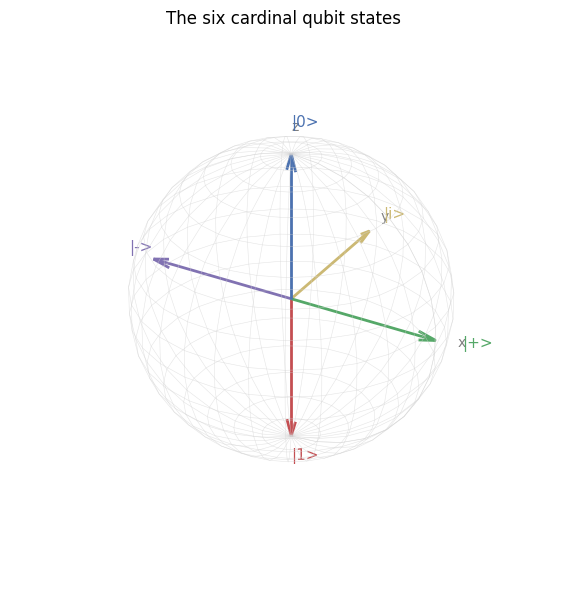

In [22]:
def plot_bloch(states, title="Bloch sphere"):
    "states: list of (label, statevector). Draws arrows on a wireframe sphere."
    fig = plt.figure(figsize=(6, 6))
    ax = fig.add_subplot(111, projection="3d")

    # wireframe sphere
    u = np.linspace(0, 2*np.pi, 30); v = np.linspace(0, np.pi, 18)
    ax.plot_wireframe(np.outer(np.cos(u), np.sin(v)),
                      np.outer(np.sin(u), np.sin(v)),
                      np.outer(np.ones_like(u), np.cos(v)),
                      color="lightgray", linewidth=0.4, alpha=0.6)

    # coordinate axes
    for vec, lab in [((1,0,0), "x"), ((0,1,0), "y"), ((0,0,1), "z")]:
        ax.plot([0, vec[0]], [0, vec[1]], [0, vec[2]], color="gray", lw=0.8)
        ax.text(1.15*vec[0], 1.15*vec[1], 1.15*vec[2], lab, color="gray")

    colors = ["#4C72B0", "#C44E52", "#55A868", "#8172B2", "#CCB974", "#64B5CD"]
    for (label, st), col in zip(states, colors):
        r = bloch_vector(st)
        ax.quiver(0, 0, 0, r[0], r[1], r[2], color=col, lw=2, arrow_length_ratio=0.12)
        ax.text(1.18*r[0], 1.18*r[1], 1.18*r[2], label, color=col, fontsize=11)

    ax.set_box_aspect([1, 1, 1]); ax.set_xlim(-1, 1); ax.set_ylim(-1, 1); ax.set_zlim(-1, 1)
    ax.set_title(title); ax.set_axis_off()
    plt.tight_layout(); plt.show()

plot_bloch([("|0>", ket0), ("|1>", ket1), ("|+>", ket_plus),
            ("|->", ket_minus), ("|i>", ket_i)],
           title="The six cardinal qubit states")

### 7.1 A gate is a rotation
The Hadamard sends $|0\rangle$ (north pole) to $|+\rangle$ (equator). On the sphere this is a rotation -
the *same* z-to-x basis change you did physically by re-orienting the SG magnet. Watch the arrow move.

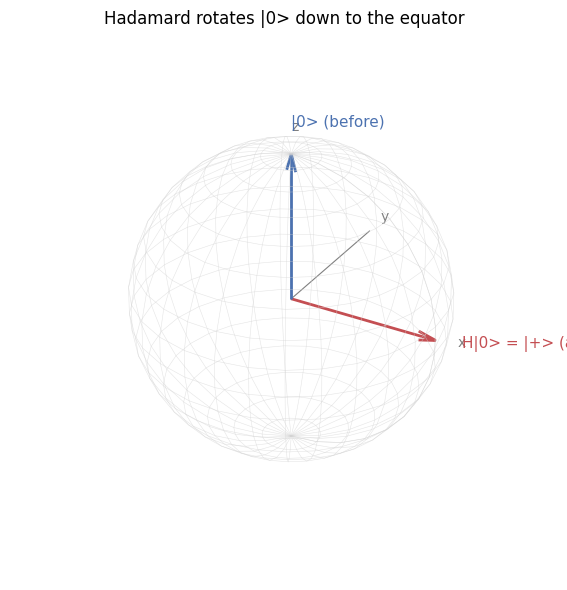

In [23]:
plot_bloch([("|0> (before)", ket0), ("H|0> = |+> (after)", H @ ket0)],
           title="Hadamard rotates |0> down to the equator")

### 7.2 Continuous rotation about an axis
The unitary $R_{\hat n}(\theta) = e^{-i\,\theta\,(\hat n\cdot\vec\sigma)/2}$ rotates the Bloch vector by angle
$\theta$ about axis $\hat n$. Below we rotate $|0\rangle$ about the $y$-axis in steps and watch it sweep from
the north pole down toward the equator - exactly how a gate "dials in" a superposition.

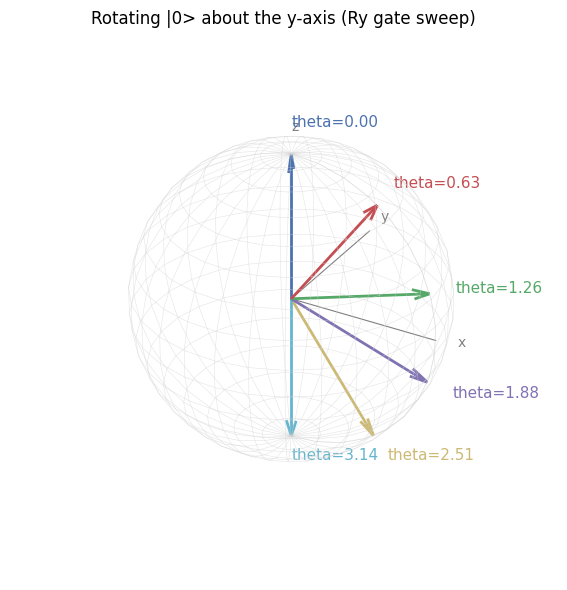

z-coordinate <sz> as we rotate (1 = north pole |0>, 0 = equator):
   theta = 0.00  ->  <sz> = +1.000
   theta = 0.63  ->  <sz> = +0.809
   theta = 1.26  ->  <sz> = +0.309
   theta = 1.88  ->  <sz> = -0.309
   theta = 2.51  ->  <sz> = -0.809
   theta = 3.14  ->  <sz> = -1.000


In [24]:
def rotation(axis, angle):
    "R_n(theta) = exp(-i theta/2 (n . sigma)), axis is a 3-vector (need not be unit)."
    n = np.array(axis, dtype=float); n = n / np.linalg.norm(n)
    n_dot_sigma = n[0]*sx + n[1]*sy + n[2]*sz
    return expm_unitary(n_dot_sigma, t=angle/2)

angles = np.linspace(0, np.pi, 6)
states = [(f"theta={a:.2f}", rotation([0, 1, 0], a) @ ket0) for a in angles]
plot_bloch(states, title="Rotating |0> about the y-axis (Ry gate sweep)")

print("z-coordinate <sz> as we rotate (1 = north pole |0>, 0 = equator):")
for a in angles:
    st = rotation([0, 1, 0], a) @ ket0
    print(f"   theta = {a:4.2f}  ->  <sz> = {expectation(sz, st):+.3f}")

---
## 8. For Practice

These are based directly on the cells above - copy a function, change an input, re-run. Suggested solutions are
hidden in the collapsed cell at the very end (look only after trying).

1. **A new state.** Build $|\psi\rangle = \tfrac{1}{\sqrt3}|0\rangle + \sqrt{\tfrac23}\,e^{i\pi/4}|1\rangle$.
   Check it is normalized, then find $P(0)$ and $P(1)$ for a $z$-measurement using `born_probs`.

2. **Predict, then simulate.** For your state above, compute $\langle Z\rangle$ with `expectation`, then run
   3000 shots with `measure_once` and confirm the Monte-Carlo average agrees.

3. **Incompatibility by hand.** Verify $[\,\sigma_x,\sigma_z\,] \ne 0$ but $[\,\sigma_z,\sigma_z\,] = 0$.
   What does each result say about measuring those observables in sequence?

4. **Pauli decomposition.** Decompose the gate $S = \begin{pmatrix}1&0\\0&i\end{pmatrix}$ in the Pauli basis
   with `pauli_decompose`. Is $S$ Hermitian? Is it unitary?

5. **Bloch geography.** Use `plot_bloch` to display the eigenstates of $\sigma_y$ (the states $|i\rangle$ and
   $|{-i}\rangle = (|0\rangle - i|1\rangle)/\sqrt2$). Which axis do they lie on, and why?

6. **Build a rotation.** Use `rotation` to make the gate that takes $|0\rangle$ exactly to $|1\rangle$
   (the NOT gate). Which axis and angle did you need? Compare your matrix with $\sigma_x$.

In [25]:
# === Try your answers here ===
# (scratch cell - write code for the exercises above)

<details>
<summary><b>Suggested solutions (click to expand)</b></summary>

```python
# 1.
psi = (1/np.sqrt(3))*ket0 + np.sqrt(2/3)*np.exp(1j*np.pi/4)*ket1
print("norm:", norm(psi))                         # -> 1.0
print(born_probs(psi, Z))                          # P(+1)=1/3, P(-1)=2/3

# 2.
print("<Z> =", expectation(Z, psi))                # 1/3 - 2/3 = -1/3
sample = [measure_once(psi, Z)[0] for _ in range(3000)]
print("MC average:", np.mean(sample))              # ~ -0.333

# 3.
print(np.allclose(comm(sx, sz), 0))                # False -> incompatible
print(np.allclose(comm(sz, sz), 0))                # True  -> compatible with itself

# 4.
S = np.array([[1,0],[0,1j]], dtype=complex)
print(pauli_decompose(S))                          # cI=(1+i)/2, cZ=(1-i)/2
print("Hermitian:", is_hermitian(S), " Unitary:", is_unitary(S))  # False, True

# 5.
ket_minus_i = (ket0 - 1j*ket1)/np.sqrt(2)
plot_bloch([("|i>", ket_i), ("|-i>", ket_minus_i)])   # they sit on the +/- y axis

# 6.
NOT = rotation([1,0,0], np.pi)     # rotate pi about x
print(np.allclose(NOT @ ket0, ket1))                  # True (up to global phase)
print(np.round(NOT, 3))                                # equals sigma_x up to phase -i
```
</details>

---
### Where this leads
You now have the full single-qubit toolkit: states, measurement, collapse, Hermitian observables, unitary
gates, the Pauli basis, and the Bloch sphere. **Next** we use exactly these objects to (a) read gates as
Bloch-sphere rotations and (b) assemble them into algorithms that work by *manipulating the
interference*. Next, we will discuss the two-qubit formalism - tensor products, Bell states etc. That will essentially
reuse every function above, just on a four-dimensional space.